In [92]:
# Import libraries

import pandas as pd
import seaborn as sns
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
plt.style.use('ggplot')
from matplotlib.pyplot import figure

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12,8) #Adjusts the configuration of he plots we willl create

# Read in the data
df = pd.read_csv('movies.csv')

In [28]:
# Let's look at the data

df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344,Orion Pictures,98.0


In [54]:
# View dataframe schema and identify data quality issues, missing data, or useless fields
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7668 entries, 0 to 7667
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          7668 non-null   object 
 1   rating        7591 non-null   object 
 2   genre         7668 non-null   object 
 3   year          7668 non-null   int64  
 4   released      7666 non-null   object 
 5   score         7668 non-null   float64
 6   votes         7668 non-null   float64
 7   director      7668 non-null   object 
 8   writer        7665 non-null   object 
 9   star          7667 non-null   object 
 10  country       7665 non-null   object 
 11  budget        7668 non-null   int64  
 12  gross         7668 non-null   int64  
 13  company       7651 non-null   object 
 14  runtime       7664 non-null   float64
 15  year_correct  7668 non-null   object 
dtypes: float64(3), int64(3), object(10)
memory usage: 958.6+ KB


In [94]:
# Change data type of budget column

df = df.astype({'budget': 'int64', 'gross': 'int64'})

In [34]:
# Descriptive statistics for numeric columns
numeric_summary = df.describe().T
numeric_summary

,count,mean,std,min,25%,50%,75%,max
year,7668.0,2.000405e+03,1.115351e+01,1980.0,1991.00,2000.0,2010.0,2.020000e+03
score,7668.0,6.390454e+00,9.686545e-01,1.9,5.80,6.5,7.1,9.300000e+00
votes,7668.0,8.808694e+04,1.632954e+05,7.0,9100.00,33000.0,93000.0,2.400000e+06
budget,7668.0,3.131756e+07,3.575273e+07,3000.0,14000000.00,20500000.0,32000000.0,3.560000e+08
gross,7668.0,7.706370e+07,1.639191e+08,309.0,4681150.75,20205757.0,72620218.5,2.847246e+09
runtime,7664.0,1.072616e+02,1.858125e+01,55.0,95.00,104.0,116.0,3.660000e+02


In [37]:
# Let's see if there is any missing data - Data cleaning

for col in df.columns:
    pct_missing = np.mean(df[col].isnull())
    print('{} - {}%'.format(col, pct_missing))

name - 0.0%
rating - 0.010041731872717789%
genre - 0.0%
year - 0.0%
released - 0.0002608242044861763%
score - 0.0%
votes - 0.0%
director - 0.0%
writer - 0.0003912363067292645%
star - 0.00013041210224308815%
country - 0.0003912363067292645%
budget - 0.0%
gross - 0.0%
company - 0.002217005738132499%
runtime - 0.0005216484089723526%
year_correct - 0.0%


In [93]:
# Fill NaN values in numeric columns with missing values with median

df[['budget', 'gross', 'votes', 'score']] = df[['budget', 'gross', 'votes', 'score']].apply(
    lambda col: col.fillna(col.median())
)

# Fill null

In [95]:
# Create correct year column
df['year_correct'] = df['released'].astype(str).str[:4]

In [96]:
df = df.sort_values(by=['gross'], inplace=False, ascending=False)

In [51]:
# Give dataframe scrolling view

pd.set_option('display.max_rows', 20)

In [97]:
# Drop duplicates

df.drop_duplicates()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,year_correct
5445,Avatar,PG-13,Action,2009,"December 18, 2009 (United States)",7.8,1100000.0,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162.0,Dece
7445,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8.4,903000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181.0,Apri
3045,Titanic,PG-13,Drama,1997,"December 19, 1997 (United States)",7.8,1100000.0,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194.0,Dece
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,"December 18, 2015 (United States)",7.8,876000.0,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000,2069521700,Lucasfilm,138.0,Dece
7244,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018 (United States)",8.4,897000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000,2048359754,Marvel Studios,149.0,Apri
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3818,"Love, Honor and Obey",R,Comedy,2000,"February 9, 2001 (United States)",6.5,5200.0,Dominic Anciano,Dominic Anciano,Sadie Frost,United Kingdom,20500000,1400,British Broadcasting Corporation (BBC),103.0,Febr
7625,The Untold Story,NaN,Comedy,2019,"January 11, 2019 (United States)",5.7,320.0,Shane Stanley,Lee Stanley,Miko Hughes,United States,20500000,790,Visual Arts Entertainment,104.0,Janu
7580,Run with the Hunted,Not Rated,Crime,2019,"June 26, 2020 (United States)",5.2,735.0,John Swab,John Swab,Ron Perlman,United States,20500000,682,Roxwell Films,93.0,June
2417,Madadayo,NaN,Drama,1993,"April 17, 1993 (Japan)",7.3,5100.0,Akira Kurosawa,Ishirô Honda,Tatsuo Matsumura,Japan,11900000,596,DENTSU Music And Entertainment,134.0,Apri


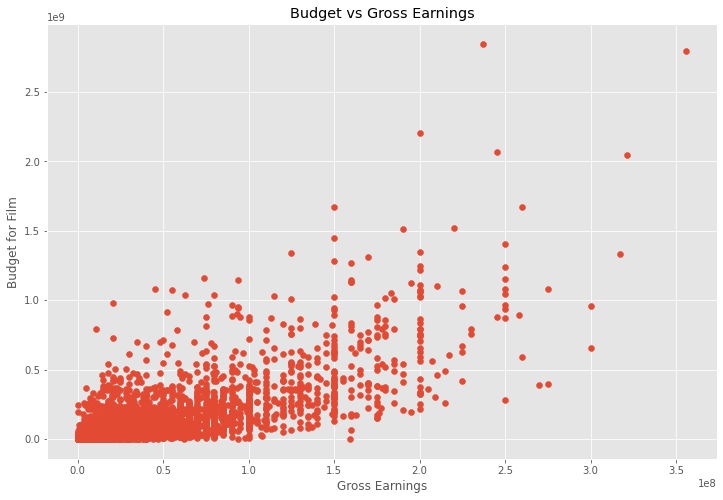

In [87]:
# Scatter plot with budget vs gross

plt.scatter(x=df['budget'], y=df['gross'])
plt.title('Budget vs Gross Earnings')

plt.xlabel('Gross Earnings')
plt.ylabel('Budget for Film')
plt.show()

<AxesSubplot:xlabel='budget', ylabel='gross'>

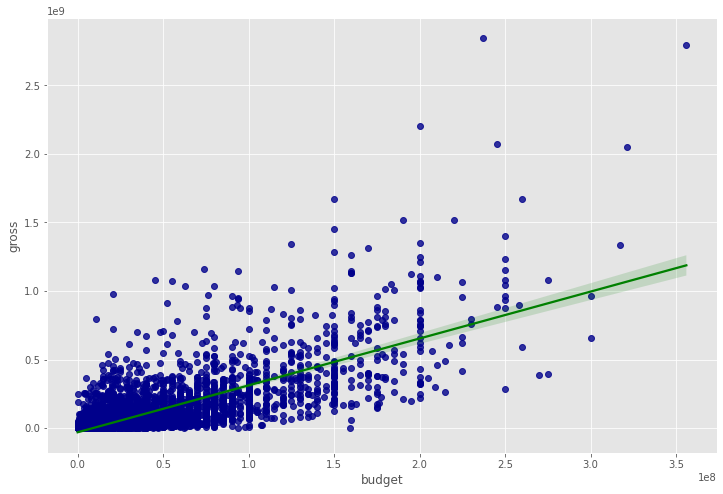

In [64]:
# Plot the budget vs gross using seaborn - regression line

sns.regplot(x='budget', y='gross', data=df, scatter_kws={"color": "darkblue"}, line_kws={"color": "green"})

In [88]:
# Let's start looking at correlation

df.corr()

,year,score,votes,budget,gross,runtime
year,1.000000,0.098013,0.222573,0.291690,0.259504,0.120811
score,0.098013,1.000000,0.409157,0.061931,0.185563,0.399408
votes,0.222573,0.409157,1.000000,0.460968,0.632120,0.309145
budget,0.291690,0.061931,0.460968,1.000000,0.745881,0.273363
gross,0.259504,0.185563,0.632120,0.745881,1.000000,0.244360
runtime,0.120811,0.399408,0.309145,0.273363,0.244360,1.000000


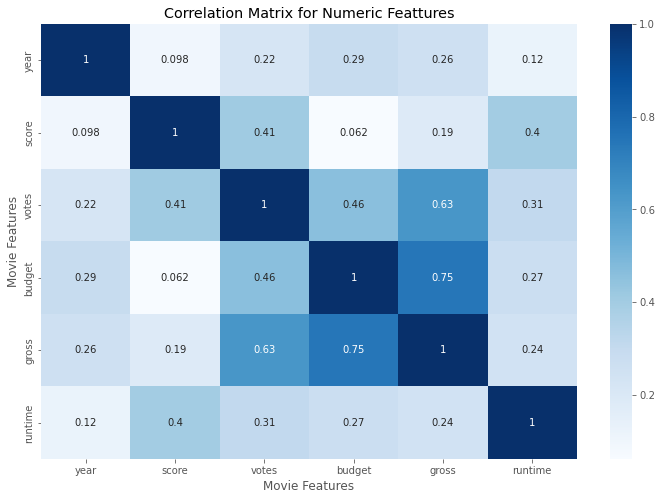

In [89]:
# High correlation between budget and gross

correlation_matrix = df.corr()

sns.heatmap(correlation_matrix, cmap="Blues", annot=True)

plt.title('Correlation Matrix for Numeric Feattures')
plt.xlabel('Movie Features')
plt.ylabel('Movie Features')

plt.show()

In [90]:
# 

df_numerized = df

for col_name in df_numerized.columns:
    if(df_numerized[col_name].dtype == 'object'):
        df_numerized[col_name] = df_numerized[col_name].astype('category')
        df_numerized[col_name] = df_numerized[col_name].cat.codes
        
df_numerized

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,year_correct
5445,533,5,0,2009,696,7.8,1100000.0,1155,1778,2334,55,237000000,2847246203,2253,162.0,10
7445,535,5,0,2019,183,8.4,903000.0,162,743,2241,55,356000000,2797501328,1606,181.0,8
3045,6896,5,6,1997,704,7.8,1100000.0,1155,1778,1595,55,200000000,2201647264,2253,194.0,10
6663,5144,5,0,2015,698,7.8,876000.0,1125,2550,524,55,245000000,2069521700,1540,138.0,10
7244,536,5,0,2018,192,8.4,897000.0,162,743,2241,55,321000000,2048359754,1606,149.0,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3818,3360,6,4,2000,1119,6.5,5200.0,730,1123,2319,54,20500000,1400,477,103.0,11
7625,6720,-1,4,2019,1149,5.7,320.0,2546,2565,1915,55,20500000,790,2308,104.0,12
7580,4664,3,5,2019,1835,5.2,735.0,1445,2203,2278,55,20500000,682,1992,93.0,14
2417,3406,-1,6,1993,85,7.3,5100.0,33,1718,2563,27,11900000,596,796,134.0,8


In [98]:
df

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,year_correct
5445,Avatar,PG-13,Action,2009,"December 18, 2009 (United States)",7.8,1100000.0,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162.0,Dece
7445,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8.4,903000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181.0,Apri
3045,Titanic,PG-13,Drama,1997,"December 19, 1997 (United States)",7.8,1100000.0,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194.0,Dece
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,"December 18, 2015 (United States)",7.8,876000.0,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000,2069521700,Lucasfilm,138.0,Dece
7244,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018 (United States)",8.4,897000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000,2048359754,Marvel Studios,149.0,Apri
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3818,"Love, Honor and Obey",R,Comedy,2000,"February 9, 2001 (United States)",6.5,5200.0,Dominic Anciano,Dominic Anciano,Sadie Frost,United Kingdom,20500000,1400,British Broadcasting Corporation (BBC),103.0,Febr
7625,The Untold Story,NaN,Comedy,2019,"January 11, 2019 (United States)",5.7,320.0,Shane Stanley,Lee Stanley,Miko Hughes,United States,20500000,790,Visual Arts Entertainment,104.0,Janu
7580,Run with the Hunted,Not Rated,Crime,2019,"June 26, 2020 (United States)",5.2,735.0,John Swab,John Swab,Ron Perlman,United States,20500000,682,Roxwell Films,93.0,June
2417,Madadayo,NaN,Drama,1993,"April 17, 1993 (Japan)",7.3,5100.0,Akira Kurosawa,Ishirô Honda,Tatsuo Matsumura,Japan,11900000,596,DENTSU Music And Entertainment,134.0,Apri


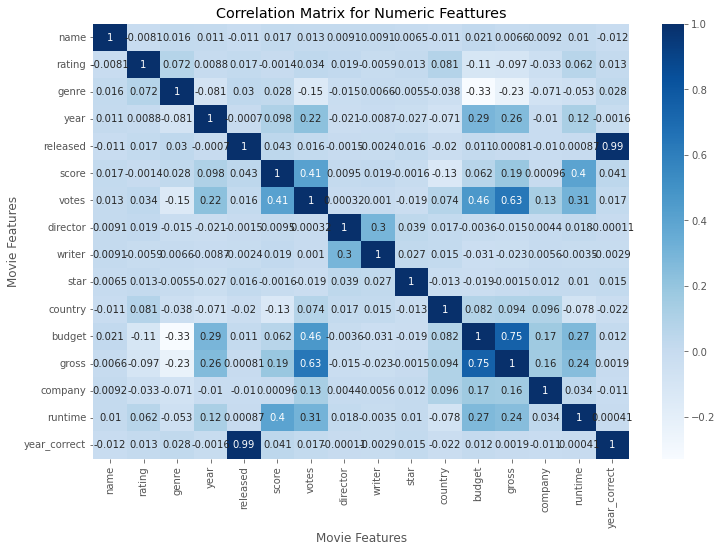

In [99]:
# High correlation between budget and gross

correlation_matrix = df_numerized.corr()

sns.heatmap(correlation_matrix, cmap="Blues", annot=True)

plt.title('Correlation Matrix for Numeric Feattures')
plt.xlabel('Movie Features')
plt.ylabel('Movie Features')

plt.show()

In [100]:
df_numerized.corr()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,year_correct
name,1.000000,-0.008069,0.016355,0.011453,-0.011311,0.017105,0.013056,0.009079,0.009081,0.006472,-0.010737,0.020921,0.006601,0.009211,0.010392,-0.011725
rating,-0.008069,1.000000,0.072423,0.008779,0.016613,-0.001440,0.033513,0.019483,-0.005921,0.013405,0.081244,-0.108776,-0.097213,-0.032943,0.062145,0.013475
genre,0.016355,0.072423,1.000000,-0.081261,0.029822,0.027965,-0.145291,-0.015258,0.006567,-0.005477,-0.037615,-0.328484,-0.233385,-0.071067,-0.052711,0.028397
year,0.011453,0.008779,-0.081261,1.000000,-0.000695,0.098013,0.222573,-0.020795,-0.008656,-0.027242,-0.070938,0.291690,0.259504,-0.010431,0.120811,-0.001562
released,-0.011311,0.016613,0.029822,-0.000695,1.000000,0.042824,0.015959,-0.001478,-0.002404,0.015777,-0.020427,0.011120,0.000806,-0.010474,0.000868,0.993694
score,0.017105,-0.001440,0.027965,0.098013,0.042824,1.000000,0.409157,0.009540,0.019361,-0.001636,-0.133323,0.061931,0.185563,0.000960,0.399408,0.041031
votes,0.013056,0.033513,-0.145291,0.222573,0.015959,0.409157,1.000000,0.000316,0.001039,-0.019196,0.073562,0.460968,0.632120,0.133336,0.309145,0.017192
director,0.009079,0.019483,-0.015258,-0.020795,-0.001478,0.009540,0.000316,1.000000,0.299067,0.039234,0.017490,-0.003584,-0.014758,0.004404,0.017624,-0.000105
writer,0.009081,-0.005921,0.006567,-0.008656,-0.002404,0.019361,0.001039,0.299067,1.000000,0.027245,0.015343,-0.030641,-0.023064,0.005646,-0.003511,-0.002892
star,0.006472,0.013405,-0.005477,-0.027242,0.015777,-0.001636,-0.019196,0.039234,0.027245,1.000000,-0.012998,-0.018534,-0.001529,0.012442,0.010174,0.015406


In [101]:
correlation_mat = df_numerized.corr()

corr_pairs = correlation_mat.unstack()

corr_pairs

name          name            1.000000
              rating         -0.008069
              genre           0.016355
              year            0.011453
              released       -0.011311
                                ...   
year_correct  budget          0.012231
              gross           0.001940
              company        -0.010726
              runtime         0.000410
              year_correct    1.000000
Length: 256, dtype: float64

In [106]:
sorted_pairs = corr_pairs.sort_values()

with pd.option_context('display.max_rows', None):
    display(sorted_pairs)

budget        genre          -0.328484
genre         budget         -0.328484
              gross          -0.233385
gross         genre          -0.233385
genre         votes          -0.145291
votes         genre          -0.145291
score         country        -0.133323
country       score          -0.133323
budget        rating         -0.108776
rating        budget         -0.108776
gross         rating         -0.097213
rating        gross          -0.097213
genre         year           -0.081261
year          genre          -0.081261
runtime       country        -0.078412
country       runtime        -0.078412
genre         company        -0.071067
company       genre          -0.071067
year          country        -0.070938
country       year           -0.070938
genre         runtime        -0.052711
runtime       genre          -0.052711
genre         country        -0.037615
country       genre          -0.037615
rating        company        -0.032943
company       rating     

In [108]:
high_corr = sorted_pairs[(sorted_pairs) > 0.5]

with pd.option_context('display.max_rows', None):
    display(high_corr)

votes         gross           0.632120
gross         votes           0.632120
              budget          0.745881
budget        gross           0.745881
released      year_correct    0.993694
year_correct  released        0.993694
name          name            1.000000
company       company         1.000000
gross         gross           1.000000
budget        budget          1.000000
country       country         1.000000
star          star            1.000000
writer        writer          1.000000
director      director        1.000000
votes         votes           1.000000
score         score           1.000000
released      released        1.000000
year          year            1.000000
genre         genre           1.000000
rating        rating          1.000000
runtime       runtime         1.000000
year_correct  year_correct    1.000000
dtype: float64

In [109]:
# Votes and budget have the highest correlation to gross earnings

In [110]:
# Company has low correlation